## Example of Creating Domains with River Walls

An alternative method to simulate walls (or levees) is to use `riverWalls`. Think of  `riverWalls` as infinitely thin walls. To set these up we need to build our mesh with  `breaklines` to define where the wall will occur and also how to apply them during the evolution by calling `create_riverWalls`. 

First setup the mesh.

We setup a dictionary to contain the x,y,z information of each of the river walls in our simulation. In this case 3 river walls associated with wall1 to wall3. 

Look carefully at the mesh produced and notice the straight lines in the mesh at the location of the walls.

### Setup Notebook for Visualisation and Animation

We are using the format of a jupyter notebook. As such we need to setup inline matplotlib plotting and animation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Allow inline jshtml animations
from matplotlib import rc
rc('animation', html='jshtml')

### Import ANUGA

We assume that anuga has been installed. If so we can import anuga. 

In [2]:
import anuga

### Create an ANUGA domain with create_domain_from_regions 

ANUGA is based on triangles and so the mesh can conform to interesting geometrical structures. In our example the steps define an interesting geometry. Let's conform our mesh to the steps.

We will use the construction function `anuga.create_domain_from_regions`. This function needs at least a polygon which defines the boundary of the region, and a tagging of the sections of the boundry polygon, which will allow us to specify specific boundary conditions associated with the tagged sections of the boundary.

We wil do this using the function `anuga.create_domain_from_regions`. In addition we aline the mesh with our `riverwalls` which will represent the position of our three walls. 

Figure files for each frame will be stored in _plot


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Easting (m)', ylabel='Northing (m)'>,
  <matplotlib.lines.Line2D at 0x79e419f09400>])

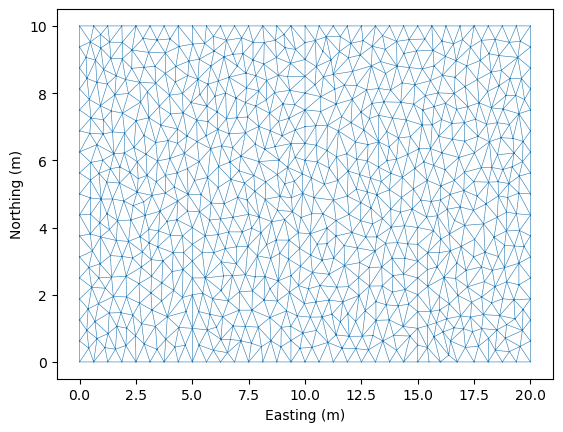

In [3]:
bounding_polygon = [[0.0, 0.0],
                    [20.0, 0.0],
                    [20.0, 10.0],
                    [0.0, 10.0]]

boundary_tags={'bottom': [0],
               'right': [1],
               'top': [2],
               'left': [3]
              }


riverWalls = { 'wall1': [[5.0,0.0,   0.5], [5.0,4.0,  0.5]],
               'wall2': [[15.0,0.0, -0.5], [15.0,4.0,-0.5]],
               'wall3': [[10.0,10.0, 0.0], [10.0,6.0, 0.0]]
             }

#bline = [[[0.1,5.0,0.0],[19.9,5.0,0.0]]]
              
domain = anuga.create_domain_from_regions(bounding_polygon, 
                                           boundary_tags,
                                           maximum_triangle_area = 0.2,
                                           breaklines = riverWalls.values())

domain.set_name('domain3')
domain.set_store_vertices_smoothly(False)

# Plot the resulting Mesh
domain.set_plotter()
domain.triplot(linewidth = 0.4)

Note: Look closely at the mesh and you will see three straight lines in the mesh generated by the breaklines. THis use of breakline can be very useful to build structures into the mesh (such as valley floors, buildings, and of course in this case riverwalls (or levees)).

### Initial and Boundary Conditions and River walls


In [4]:
#Initial Conditions
domain.set_quantity('elevation', lambda x,y : -x/10, location='centroids') # Use function for elevation
domain.set_quantity('friction', 0.01, location='centroids')                # Constant friction 
domain.set_quantity('stage', expression='elevation', location='centroids') # Dry Bed 


# Boundary Conditions
Bi = anuga.Dirichlet_boundary([0.4, 0, 0])         # Inflow
Bo = anuga.Dirichlet_boundary([-2, 0, 0])          # Inflow
Br = anuga.Reflective_boundary(domain)            # Solid reflective wall

domain.set_boundary({'left': Bi, 'right': Bo, 'top': Br, 'bottom': Br})

# Setup RiverWall
domain.create_riverwalls(riverWalls, verbose=False)

Note: If we didn't call `create_riverwalls` then there would not be any backup of water.

### Evolve

Notice that we have setup the river walls to be only 1 metre high. So we would expect some overtopping of the 2nd lower step. 

In [5]:
for t in domain.evolve(yieldstep=2, duration=40):
  
    #dplotter.plot_depth_frame()
    domain.save_depth_frame(vmin=0.0, vmax=1.0)
    
    domain.print_timestepping_statistics()

    
# Read in the png files stored during the evolve loop
domain.make_depth_animation() 

Time = 0.0000 (sec), steps=0 (0s), elapsed (0s), eta (??), mem=196MB
Time = 2.0000 (sec), delta t in [0.01813369, 0.04322357] (s), steps=86 (0s), elapsed (0s), eta (7s), mem=198MB
Time = 4.0000 (sec), delta t in [0.01584979, 0.01883231] (s), steps=118 (0s), elapsed (0s), eta (6s), mem=201MB
Time = 6.0000 (sec), delta t in [0.01583185, 0.01738707] (s), steps=121 (0s), elapsed (0s), eta (5s), mem=203MB
Time = 8.0000 (sec), delta t in [0.01625105, 0.01686416] (s), steps=122 (0s), elapsed (1s), eta (4s), mem=206MB
Time = 10.0000 (sec), delta t in [0.01662976, 0.01887900] (s), steps=111 (0s), elapsed (1s), eta (3s), mem=208MB
Time = 12.0000 (sec), delta t in [0.01762579, 0.01855303] (s), steps=112 (0s), elapsed (1s), eta (3s), mem=211MB
Time = 14.0000 (sec), delta t in [0.01705865, 0.01766205] (s), steps=116 (0s), elapsed (1s), eta (3s), mem=214MB
Time = 16.0000 (sec), delta t in [0.01673190, 0.01716414] (s), steps=118 (0s), elapsed (2s), eta (3s), mem=216MB
Time = 18.0000 (sec), delta t in

### Throughflow — flow through the wall body (`Cd_through`)

By default `Cd_through=0` and the riverwall is completely impermeable below its crest (water can only cross via the Villemonte overtopping formula). Setting `Cd_through > 0` enables an orifice-flow model for water passing **through** the wall body — useful for modelling:

- Earthen levees with internal seepage
- Permeable rock walls
- Culverts embedded in a levee

The formula applied at each wall edge is:

$$Q = C_d \cdot h_\text{eff} \cdot \sqrt{2 g \, |\Delta \text{stage}|}$$

where $h_\text{eff}$ is the submerged depth on the **upstream** side (water depth below the wall crest on the driving side).

In the example below the wall crest is at $z = 0.5$, while the upstream boundary stage is only $0.4$ — **the wall is never overtopped**. We compare `Cd_through = 0.0` (completely impermeable) with `Cd_through = 0.5` (seepage enabled) to isolate the throughflow effect.

In [6]:
def run_throughflow_demo(Cd_through=0.0, duration=30):
    """
    Single-wall demo: wall crest z=0.5, upstream stage=0.4 (no overtopping).
    Returns mean water depth on the downstream half (x > 10) at end of run.
    """
    bounding_polygon = [[0, 0], [20, 0], [20, 10], [0, 10]]
    boundary_tags = {'bottom': [0], 'right': [1], 'top': [2], 'left': [3]}

    # Single wall spanning the domain at x=10, crest height z=0.5
    riverWalls = {'levee': [[10.0, 0.0, 0.5], [10.0, 10.0, 0.5]]}

    domain = anuga.create_domain_from_regions(
        bounding_polygon, boundary_tags,
        maximum_triangle_area=0.5,
        breaklines=riverWalls.values())

    domain.set_name(f'demo_Cd{Cd_through}')
    domain.set_store(False)  # no .sww output needed for this demo

    domain.set_quantity('elevation', 0.0, location='centroids')
    domain.set_quantity('friction',  0.01, location='centroids')
    domain.set_quantity('stage',     0.0, location='centroids')  # dry start

    # Upstream stage 0.4 < wall crest 0.5  →  no overtopping possible
    Bi = anuga.Dirichlet_boundary([0.4, 0.0, 0.0])
    Bo = anuga.Dirichlet_boundary([-2.0, 0.0, 0.0])
    Br = anuga.Reflective_boundary(domain)
    domain.set_boundary({'left': Bi, 'right': Bo, 'top': Br, 'bottom': Br})

    riverwallPar = {'levee': {'Cd_through': Cd_through}}
    domain.create_riverwalls(riverWalls, riverwallPar, verbose=False)

    for t in domain.evolve(yieldstep=5, duration=duration):
        domain.print_timestepping_statistics()

    # Mean depth on downstream half (x > 10)
    x     = domain.centroid_coordinates[:, 0]
    depth = (domain.get_quantity('stage').centroid_values
             - domain.get_quantity('elevation').centroid_values)
    depth = np.maximum(depth, 0.0)
    return float(np.mean(depth[x > 10]))

#### Run 1: impermeable wall (`Cd_through = 0.0`)

With the default `Cd_through = 0` and the upstream stage below the crest, no water should reach the downstream side.

In [ ]:
print("=== Cd_through = 0.0  (impermeable wall) ===")
mean_depth_0 = run_throughflow_demo(Cd_through=0.0)
print(f"\nMean downstream depth: {mean_depth_0:.5f} m")

#### Run 2: throughflow enabled (`Cd_through = 0.5`)

Now we enable throughflow. Water seeps through the wall body even though the upstream stage (0.4 m) never reaches the crest (0.5 m).

In [ ]:
print("=== Cd_through = 0.5  (seepage through wall) ===")
mean_depth_05 = run_throughflow_demo(Cd_through=0.5)
print(f"\nMean downstream depth: {mean_depth_05:.5f} m")

#### Compare the two runs

In [ ]:
labels = ['Cd_through = 0.0\n(impermeable)', 'Cd_through = 0.5\n(seepage)']
depths = [mean_depth_0, mean_depth_05]

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(labels, depths, color=['steelblue', 'tomato'], width=0.4)
ax.set_ylabel('Mean downstream depth (m)')
ax.set_title('Effect of Cd_through on downstream water depth\n(upstream stage 0.4 m, wall crest 0.5 m — no overtopping)')
for bar, val in zip(bars, depths):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.0005,
            f'{val:.4f} m', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Cd_through = 0.0 → downstream mean depth = {mean_depth_0:.5f} m  (wall is impermeable)")
print(f"  Cd_through = 0.5 → downstream mean depth = {mean_depth_05:.5f} m  (seepage through wall)")